# Child model V&V: mortality, LBWSG RR surface, and PAFs

Version-free filename by convention: rerun against each model iteration's results and
commit, so run-over-run diffs fall out of git history. This is where the LBWSG
category-ordering (interpolator scramble) fix will visibly move things:
- the interpolated RR surface should agree with the raw RRs at the category midpoints
  and decrease monotonically with birthweight (pre-fix it is scrambled),
- the calculated LBWSG PAFs should drop (Nigeria F early-neonatal ≈ 0.87 → ≈ 0.80).

In [1]:
import pandas as pd, numpy as np, pickle, re
import matplotlib.pyplot as plt
from vivarium.artifact import Artifact

location = "nigeria"
vehicle = "bouillon"
results_dir = "/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1/child/bouillon/nigeria/2026_08_28_20_20_09/results/"
artifact_dir = "/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/child/bouillon/nigeria.hdf"
paf_dir = "/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/data/model1.1/lbwsg_pafs/nigeria/2026_08_28_19_24_04/results/"
art = Artifact(artifact_dir)

## All-cause mortality: sim vs artifact

The sim's age bins (months) differ from the artifact's GBD bins, so this is a level check
on age midpoints: each sim point should sit within the range of the artifact bins it spans
(the sim bin is a person-time-weighted mixture of them).

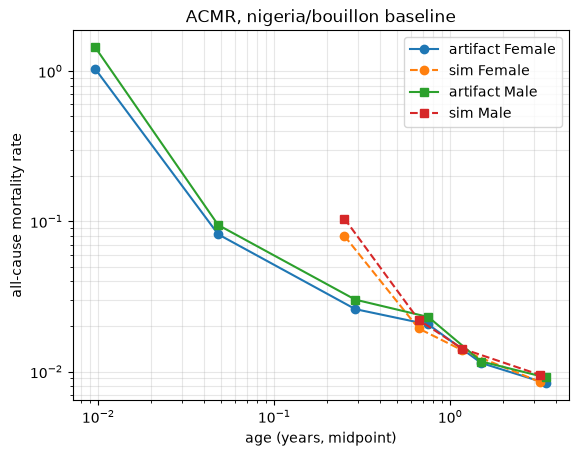

In [2]:
deaths = pd.read_parquet(results_dir + "deaths")
pt = pd.read_parquet(results_dir + "person_time_population")
cols = ["maternal_scenario", "child_scenario", "sex", "age_group"]
acmr = (deaths.groupby(cols).value.sum() / pt.groupby(cols).value.sum()).rename("sim")
acmr = acmr.xs(("baseline", "baseline")).reset_index()
sim_mid = {"0_to_5_months": 0.25, "6_to_9_months": 0.66, "10_to_17_months": 1.17, "18_to_59_months": 3.25}

art_acmr = art.load("cause.all_causes.cause_specific_mortality_rate")["draw_0"].reset_index()
art_acmr = art_acmr[art_acmr.age_start < 5]

for sex, marker in [("Female", "o"), ("Male", "s")]:
    a = art_acmr[art_acmr.sex == sex]
    plt.plot((a.age_start + a.age_end) / 2, a.draw_0, marker + "-", label=f"artifact {sex}")
    s = acmr[acmr.sex == sex]
    plt.plot(s.age_group.map(sim_mid), s.sim, marker + "--", label=f"sim {sex}")
plt.xscale("log"); plt.yscale("log"); plt.grid(which="both", alpha=0.3)
plt.xlabel("age (years, midpoint)"); plt.ylabel("all-cause mortality rate")
plt.legend(); plt.title(f"ACMR, {location}/{vehicle} baseline")
plt.show()

## LBWSG interpolated RR surface at its own knots

Evaluate the stored interpolator at each category's (gestational age, birthweight) midpoint
and compare with the raw RR for that category. If the interpolator was built correctly the
two agree (max |log ratio| ≈ 0) and RR falls monotonically with birthweight within each
gestational-age band. Pre-fix, category ordering is scrambled: large knot errors and
reversals.

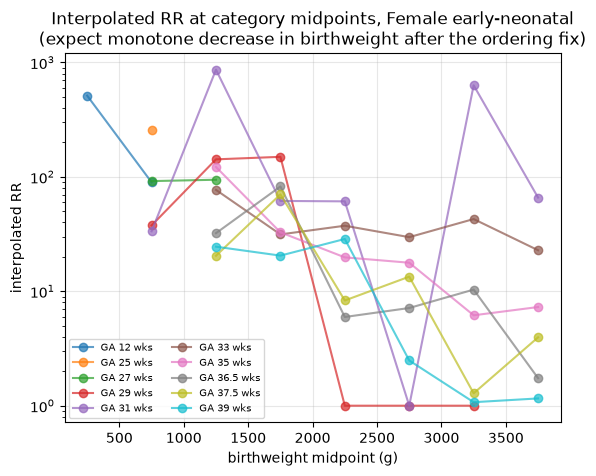

max |log(interpolated/raw)| at the knots: 4.19 | post-fix expectation: ~0


In [3]:
rr = art.load("risk_factor.low_birth_weight_and_short_gestation.relative_risk")["draw_0"].reset_index()
rr = rr[(rr.sex == "Female") & (rr.age_start == 0)].set_index("parameter").draw_0
cats = art.load("risk_factor.low_birth_weight_and_short_gestation.categories")
mids = {}
for cat, desc in cats.items():
    m = re.search(r"\[([\d.]+), ([\d.]+)\) wks, \[([\d.]+), ([\d.]+)\) g", desc)
    if m:
        ga0, ga1, bw0, bw1 = map(float, m.groups())
        mids[cat] = ((ga0 + ga1) / 2, (bw0 + bw1) / 2)

interp = art.load("risk_factor.low_birth_weight_and_short_gestation.relative_risk_interpolator")["draw_0"].reset_index()
spline = pickle.loads(bytes.fromhex(interp[(interp.sex == "Female") & (interp.age_start == 0)].draw_0.iloc[0]))

knots = pd.DataFrame(
    [(c, *mids[c], rr[c], float(np.exp(spline(mids[c][0], mids[c][1], grid=False))))
     for c in mids if c in rr.index],
    columns=["cat", "ga_mid", "bw_mid", "rr_raw", "rr_interpolated"],
)
for ga, grp in knots.sort_values("bw_mid").groupby("ga_mid"):
    plt.plot(grp.bw_mid, grp.rr_interpolated, "o-", alpha=0.7, label=f"GA {ga:g} wks")
plt.yscale("log"); plt.grid(alpha=0.3); plt.legend(fontsize=7, ncol=2)
plt.xlabel("birthweight midpoint (g)"); plt.ylabel("interpolated RR")
plt.title("Interpolated RR at category midpoints, Female early-neonatal\n(expect monotone decrease in birthweight after the ordering fix)")
plt.show()
print("max |log(interpolated/raw)| at the knots:",
      round(float(np.abs(np.log(knots.rr_interpolated / knots.rr_raw)).max()), 2),
      "| post-fix expectation: ~0")

## Calculated LBWSG PAFs

Post-fix expectation: Nigeria Female early-neonatal drops from ≈ 0.87 to ≈ 0.80.

In [4]:
import os
paf_file = os.path.join(paf_dir, os.listdir(paf_dir)[0])
paf = pd.read_parquet(paf_file)
print(paf.groupby(["age_group", "sex"]).value.mean().round(3).to_string())

age_group       sex   
early_neonatal  Female    0.869
                Male      0.878
late_neonatal   Female    0.813
                Male      0.802
